# **INE5202 - Cálculo Numérico em Computadores**
## Relatório - Exercício Programa II

### **Alunos:** João Vitor Sutter e Pedro Henrique Gimenez
### **Linguagem escolhida:** Python 3.11

## **1. Tarefa 1:** Newton e os Fractais

Implementar o método de Newton para a solução dos sistemas lineares descritos abaixo e construir os mapas: **para onde convergiu e como convergiu**. Utilizando $\epsilon = 10^{-6}$ e $k_{max} = 20$, construa os mapas descritos para os sistemas não lineares:

#### Sistema 1:
$
\begin{cases}
x^2 - y^2 - 1 = 0 \\
2xy = 0
\end{cases}
$

### Cujas soluções são:
$(x_1^*, y_1^*) = (1, 0), \quad (x_2^*, y_2^*) = (-1, 0)$

### E cuja região discretizada é:
$T = \left\{ \left(-1 + \frac{2i}{N}, -1 + \frac{2j}{N} \right) \right\}, \text{ com } N \geq 100 \text{ e } 0 \leq i, j \leq N.$


#### Sistema 2:
$
\begin{cases}
x^3 - 3xy^2 - 1 = 0 \\
3x^2 y - y^3 = 0
\end{cases}
$

### Cujas soluções são:
$(x_1^*, y_1^*) = (1, 0), \quad (x_2^*, y_2^*) = \left(-\frac{1}{2}, -\frac{\sqrt{3}}{2} \right), \quad (x_3^*, y_3^*) = \left(-\frac{1}{2}, \frac{\sqrt{3}}{2} \right)$

### E cuja região discretizada é:
$T = \left\{ \left(-1.5 + \frac{3i}{N}, -1.5 + \frac{3j}{N} \right) \right\}, \text{ com } N \geq 100 \text{ e } 0 \leq i, j \leq N.$


## Solução
Inicialmente, foi criada uma função `newton` que recebe como parâmetros as funções `f1` e `f2`, correspondentes às linhas 1 e 2 do sistema; o jacobiano `jacobian`; um chute inicial `x` e `y` e um número máximo de iterações `max_iter`. A função retorna um ponto (x, y), que é a aproximação encontrada para a solução.

In [ ]:
def newton(x, y, jacobian, f1, f2, max_iter):
    """
    Método de Newton.
    x: valor inicial para x.
    y: valor inicial para y.
    jacobian: função que retorna a matriz jacobiana.
    f1 e f2: funções que retornam os valores de f1(x, y) e f2(x, y).
    """

    for _ in range(max_iter):
        F = np.array([f1(x, y), f2(x, y)])
        J = jacobian(x, y)
        delta = np.linalg.solve(J, -F)

        x += delta[0]
        y += delta[1]

    return x, y

Para modelar os sistemas lineares, foram criadas as classes `Sistema1` e `Sistema2`, que herdam da classe `SistemaLinear`. A classe `SistemaLinear` possui os métodos `f1` e `f2`, que calculam os resultados das funções correspondentes a cada linha do sistema, e um método `jacobian`, que retorna a matriz jacobiana para determinados valores de x e y.

In [ ]:
class SistemaLinear(ABC):
    def __init__(self, solutions):
        self.solutions = solutions

    @abstractmethod
    def f1(self, x, y):
        pass

    @abstractmethod
    def f2(self, x, y):
        pass

    @abstractmethod
    def jacobian(self, x, y):
        pass

Para construir os gráficos, foi criada a classe Graph, responsável pela lógica de construção de gráficos. Ela possui métodos para computar o gráfico de "como convergiu" ou o gráfico de "para onde convergiu", com base no sistema linear passado como argumento.


Veja abaixo o método plot_first_graph, que plota o gráfico de "para onde convergiu":

In [ ]:
    def plot_first_graph(self, sistema, colors, labels, plot_range):
        """Gráfico 1: para onde convergiu"""

        x_axis = np.linspace(start=plot_range[0], stop=plot_range[1], num=self.n)
        y_axis = x_axis

        to_plot = np.zeros((self.n, self.n))

        for i in range(self.n):
            for j in range(self.n):
                x, y = newton(x_axis[j], y_axis[i], sistema.jacobian, sistema.f1, sistema.f2, max_iter=20)

                for solution_index, solution in enumerate(sistema.solutions):
                    # Define a cor do ponto de acordo com a solução para a qual ele converge

                    if np.linalg.norm(np.array([x, y]) - np.array(solution)) <= self.precision:
                        to_plot[self.n - i - 1][j] = solution_index + 1
                        break

        boundaries = np.arange(len(colors) + 1) - 0.5
        norm = BoundaryNorm(boundaries=boundaries, ncolors=(len(colors) + 1))
        cmap = ListedColormap(colors)
        plt.imshow(to_plot, cmap=cmap, norm=norm, extent=(plot_range[0], plot_range[1], plot_range[0], plot_range[1]))

        colorbar = plt.colorbar(ticks=range(len(colors)))
        colorbar.ax.set_yticklabels(labels)

        solution_points = np.array(sistema.solutions)
        plt.scatter(
            solution_points[:, 0],
            solution_points[:, 1],
            color="grey",
            edgecolors="black",
            s=50,
            zorder=5,
            label="Soluções exatas",
        )

        plt.title("Regiões de convergência")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.show()

Passando o sistema 1 como argumento, obtemos o seguinte gráfico:

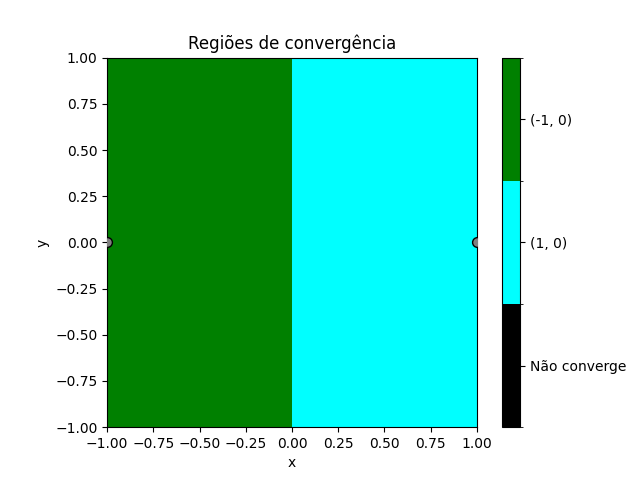

É possível observar que o método de Newton converge para as soluções esperadas, (1, 0) e (-1, 0), a partir de qualquer ponto da região discretizada. Adicionalmente, é perceptível que qualquer ponto (x, y) tal que x > 0 convergirá para (1, 0), e qualquer ponto (x, y) tal que x < 0 convergirá para (-1, 0).

O sistema 2, por sua vez, apresenta o seguinte gráfico:

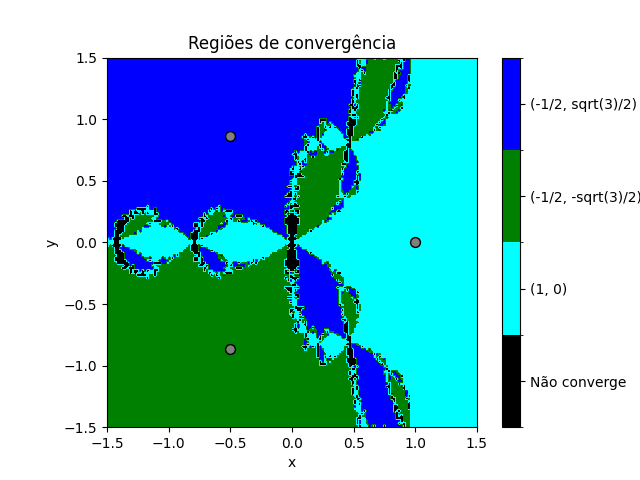

Neste caso, é possível observar que a maioria dos pontos converge para alguma das soluções. Contudo, há certos pontos que constituem uma exceção - são aqueles que estão pintados de preto. Isso ocorre porque o método de Newton só converge se a escolha do chute inicial for adequada. Também é notória a estrutura simétrica do gráfico.


O método plot_second_graph, em contrapartida, plota o gráfico de "como convergiu". Veja abaixo o código:

In [ ]:
    def plot_second_graph(self, sistema, plot_range):
        """Gráfico 2: como convergiu"""

        x_axis = np.linspace(start=plot_range[0], stop=plot_range[1], num=self.n)
        y_axis = x_axis.copy()

        to_plot = np.zeros((self.n, self.n))

        for i in range(self.n):
            for j in range(self.n):
                to_plot[self.n - i - 1][j] = self.paint_solution(
                    sistema, x_axis[j], y_axis[i], max_iter=20
                )

        cmap = plt.get_cmap("viridis")
        cmap.set_under("black")  # Set the color for zero values

        plt.imshow(to_plot, cmap=cmap, extent=(plot_range[0], plot_range[1], plot_range[0], plot_range[1]), vmin=0.1)
        plt.colorbar(ticks=range(1, len(sistema.solutions) + 1), label="Número de iterações")

        solution_points = np.array(sistema.solutions)
        plt.scatter(
            solution_points[:, 0],
            solution_points[:, 1],
            color="grey",
            edgecolors="black",
            s=50,
            zorder=5,
            label="Soluções exatas",
        )

        plt.title("Regiões de convergência")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.show()


Em que paint_solution é uma função auxiliar que determina o número de iterações necessárias para que o ponto convirja.

O gráfico de "como convergiu" para o sistema 1 é o seguinte:

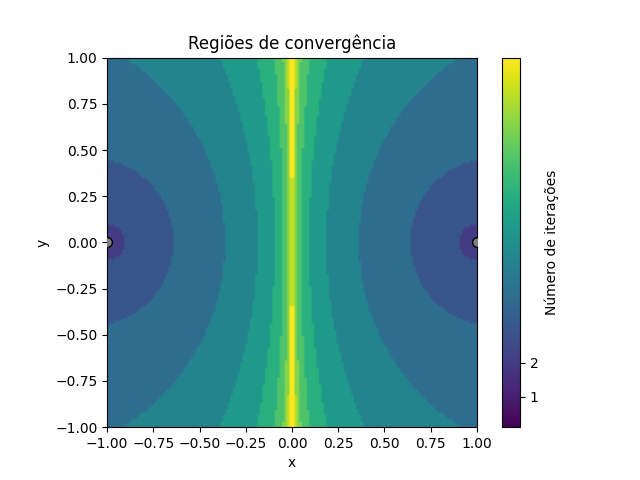

Nessa imagem, vemos uma série de camadas concêntricas ao redor das soluções, que representam a quantidade de iterações necessárias para que o método de Newton convirja para a solução. Quanto mais próximo do centro, mais próximo se está da solução real, menos iterações são necessárias, e, portanto, mais escuro fica o azul. Há um feixe amarelo no meio, justamente o conjunto de pontos próximos à fronteira entre as duas regiões do gráfico de "para onde convergiu", sendo a parte que exige mais iterações para convergir.

Já o gráfico de "como convergiu" para o sistema 2 é o seguinte:

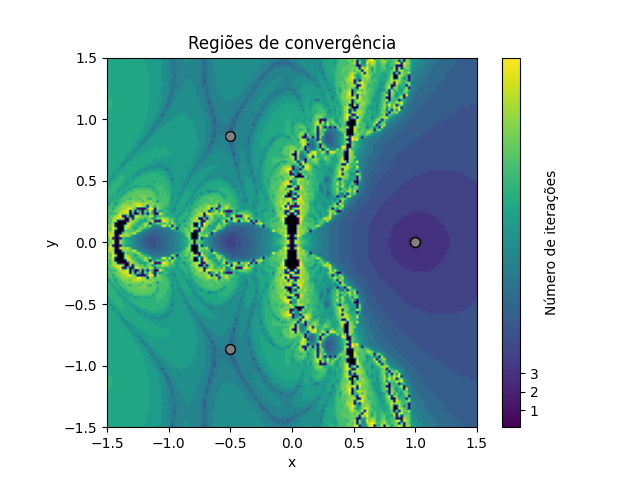

Mais uma vez é possível notar que pontos próximos as soluções demandam menos iterações. Novamente, temos pontos pretos em locais onde não há convergência, nos mesmos locais onde estavam presentes no gráfico de "para onde convergiu". Eles são rodeados de pontos amarelos, que, embora convirjam, demandam muitas iterações para tal, justamente pela proximidade com as regiões pretas. A simetria continua presente.

## **2. Tarefa 2:** Método dos Mínimos Quadrados

### **2.1) Use uma transformação para reescrever $r = \frac{a_0}{1-a_1 \cdot \cos{\theta}}$ linear nos parâmetros.**
Para realizar uma transformação linear, precisamos transformar r numa equação na forma $z = b_0+b_1\cdot \cos{\theta}$, para isso, podemos reescrever r como $\frac{1}{r}=\frac{1}{a_0}+(-\frac{a_1}{a0})\cdot \cos{\theta}$.
Assim, temos $z = \frac{1}{r}$; $b_0 = \frac{1}{a_0}$; $b_1 = -\frac{a_1}{a_0}$.

### **2.2) Utilize a linearização obtida em (2.1) para estimar os parâmetros $a_0$ e $a_1$**
Para estimar os parâmetros $a_0$ e $a_1$, precisamos resolver o sistema linear
$$ 
\begin{pmatrix}
\langle 1, 1 \rangle & \langle 1, \cos \theta \rangle \\
\langle 1, \cos \theta \rangle & \langle \cos \theta, \cos \theta \rangle
\end{pmatrix}
\cdot
\begin{pmatrix}
b_0 \\
b_1
\end{pmatrix}
=
\begin{pmatrix}
\langle 1, z \rangle \\
\langle z, \cos \theta \rangle
\end{pmatrix}
$$ 
para encontrar os valores de $b_0$ e $b_1$. Com esses valores encontrados, basta substituir nas equações $b_0 = \frac{1}{a_0}$ e $b_1 = -\frac{a_1}{a_0}$ para encontrar os valores de $a_0$ e $a_1$. Os cálculos foram realizados no Python pela seguinte função:

In [ ]:
import numpy as np

def minimos_quadrados(r_data, theta_data):
    if len(r_data) != len(theta_data):
        raise ValueError("r_data e theta_data devem ter o mesmo tamanho")
    
    # Criando matriz A
    A1 = len(theta_data)
    A2 = np.sum(np.cos(theta_data))
    A3 = A2
    A4 = np.sum(np.cos(theta_data)**2)
    
    A = np.array([[A1, A2], [A3, A4]])
    
    # Criando matriz B
    B1 = sum(1/i for i in r_data)
    B2 = np.sum(np.cos(theta_data)/r_data)
    
    B = np.array([B1, B2])
    
    # Resolvendo o sistema linear e encontrando b0 e b1
    b0, b1 = np.linalg.solve(A, B)
    
    # Encontrando a0 e a1
    a0 = 1/b0
    a1 = -a0 * b1
    
    return a0, a1, b0, b1

Com a função realizada, basta colocar como parâmetros r e $\theta$, como foi realizado aqui:

In [ ]:
r = [2.7, 2, 1.61, 1.2, 1.02]
theta = [48, 67, 83, 108, 126]

a0, a1, b0, b1 = minimos_quadrados(r, np.radians(theta))

print(f"A equação linear será z = {b0} + ({b1} * cos(theta))")
print(f"Com a0 = {a0} e a1 = {a1}.")

Assim, podemos estimar que os valores de $a_0$ e $a_1$ são aproximadamente 1.4521859650597322 e 0.702683547363648.

### **2.3) Implemente o método de Gauss-Newton e compare com os resultados do item anterior, resíduo, parâmetros e gráficos. Utilize $a_0 = (2, 1)$.**

Para implementar o método de Gauss-Newton, começamos implementando a função residual que é da forma $r_i(a) = y_i − g(x_i, a)$, em que $g(x_i, a)$ é a lei de Kepler. Então temos o seguinte código:

In [ ]:
# Função que define a lei de Kepler
def g(theta, a):
    return a[0] / (1 - a[1] * np.cos(theta))

# Função que calcula o resíduo
def residual(a):
    return r - g(theta, a)

Em seguida, calculamos a matriz Jacobiana que é só derivar a lei de Kepler em a0, depois em a1. Como é realizado aqui:

In [ ]:
# Função que calcula a matriz Jacobiana
def jacobian(a):
    n = len(theta)
    
    J = np.zeros((n, 2))
    J[:, 0] = 1 / (1 - a[1] * np.cos(theta))  # Derivada em relação a a0
    J[:, 1] = a[0] * np.cos(theta) / (1 - a[1] * np.cos(theta)) ** 2  # Derivada em relação a a1
    return J

Por fim, possuindo as funções de resíduo e jacobiana, basta aplicar o algoritmo do método de Gauss-Newton, que foi implementado da seguinte maneira:

In [ ]:
# Implementação do método de Gauss-Newton
def gauss_newton(a0, tol=1e-6, itmax=100):
    a = a0
    erro = 1
    it = 0
    while erro > tol and it < itmax:
        # Calcula o resíduo e a matriz Jacobiana
        r = residual(a)
        J = jacobian(a)

        # Calcula a atualização dos parâmetros
        JTJ = J.T @ J
        JTr = J.T @ r
        s = np.linalg.solve(JTJ, JTr)

        # Atualiza os parâmetros e o erro
        a = a + s
        erro = np.max(np.abs(s))
        it += 1

    return a, it

Assim, com todas as funções implementadas, basta testar o algoritmo com o chute inicial de $a_0=(2,1)$, como pode ser visto aqui:

In [ ]:
# Dados da tabela
r = np.array([2.70, 2.00, 1.61, 1.20, 1.02])
theta = np.deg2rad(np.array([48, 67, 83, 108, 126]))  # Convertendo ângulos para radianos

# Chute inicial
a0 = np.array([2, 1])

# Aplica o método de Gauss-Newton
a, it = gauss_newton(a0)

# Imprime os resultados
print("Parâmetros otimizados:", a)
print("Número de iterações:", it)

# Calcula o resíduo final
r_final = residual(a)
r_incio = residual([1.4521859650597322, 0.702683547363648])

# Imprime o resíduo final
print("\nResíduo Gauss-Newton:", np.sum(r_final))
print("Resíduo Linearização:", np.sum(r_incio))
print("Razão entre os resíduos:", np.sum(r_incio)/ np.sum(r_final))

É possível notar que o resultado é bem próximo do item anterior com uma diferença de aproximadamente 0.0066 em $a_0$ e de aproximadamente -0.0141 em $a_1$. É possível notar também que o resíduo final ao utilizar Gauss-Newton é menor que o da linearização em aproximadamente 4.691 vezes.

Agora, vamos plotar o gráfico com os pontos originais e a curva ajustada de cada exercício e comparar. Começamos criando uma função plotadora de gráfico que se ajusta conforme o a fornecido:

In [ ]:
import matplotlib.pyplot as plt

def grafico(a):
    plt.plot(theta, r, 'o', label='Dados originais')
    theta_fit = np.linspace(theta.min(), theta.max(), 100)
    plt.plot(theta_fit, g(theta_fit, a), '-', label='Curva ajustada (Gauss-Newton)')
    plt.xlabel('theta (rad)')
    plt.ylabel('r')
    plt.legend()
    plt.show()

Agora, plotando o gráfico do exercício anterior. 

Com $a = [1.4521859650597322, 0.702683547363648]$.

In [ ]:
a1 = [1.4521859650597322, 0.702683547363648]
grafico(a1)

Por fim, plotando o gráfico com o a encontrado com Gauss-Newton.
 
Com $a = [1.45880043, 0.6885461]$

In [ ]:
a2 = [1.45880043, 0.6885461]
grafico(a2)

A primeira impressão é a de os gráficos são quase idênticos. Porém, ao compararmos ambas as figuras com mais cautela, percebemos que o gráfico pelo método de Gauss-Newton está ligeiramente mais próximo dos pontos, como pode ser observado, por exemplo, pela análise do primeiro ponto à esquerda em ambos os gráficos.